In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# Load the Iris dataset

df = pd.read_csv('/content/IRIS.csv')

# Display the first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Check the size of the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Check data types
print("\nData types:")
print(df.dtypes)

Number of rows: 150
Number of columns: 5

Column names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [4]:
# Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [5]:
# Check the different Iris species

print("Unique species:")
print(df['species'].unique())

print("\nNumber of samples in each species:")
print(df['species'].value_counts())

Unique species:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Number of samples in each species:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [6]:
# Dataset information

print("Dataset Shape:", df.shape)
print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
df.describe()

Dataset Shape: (150, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


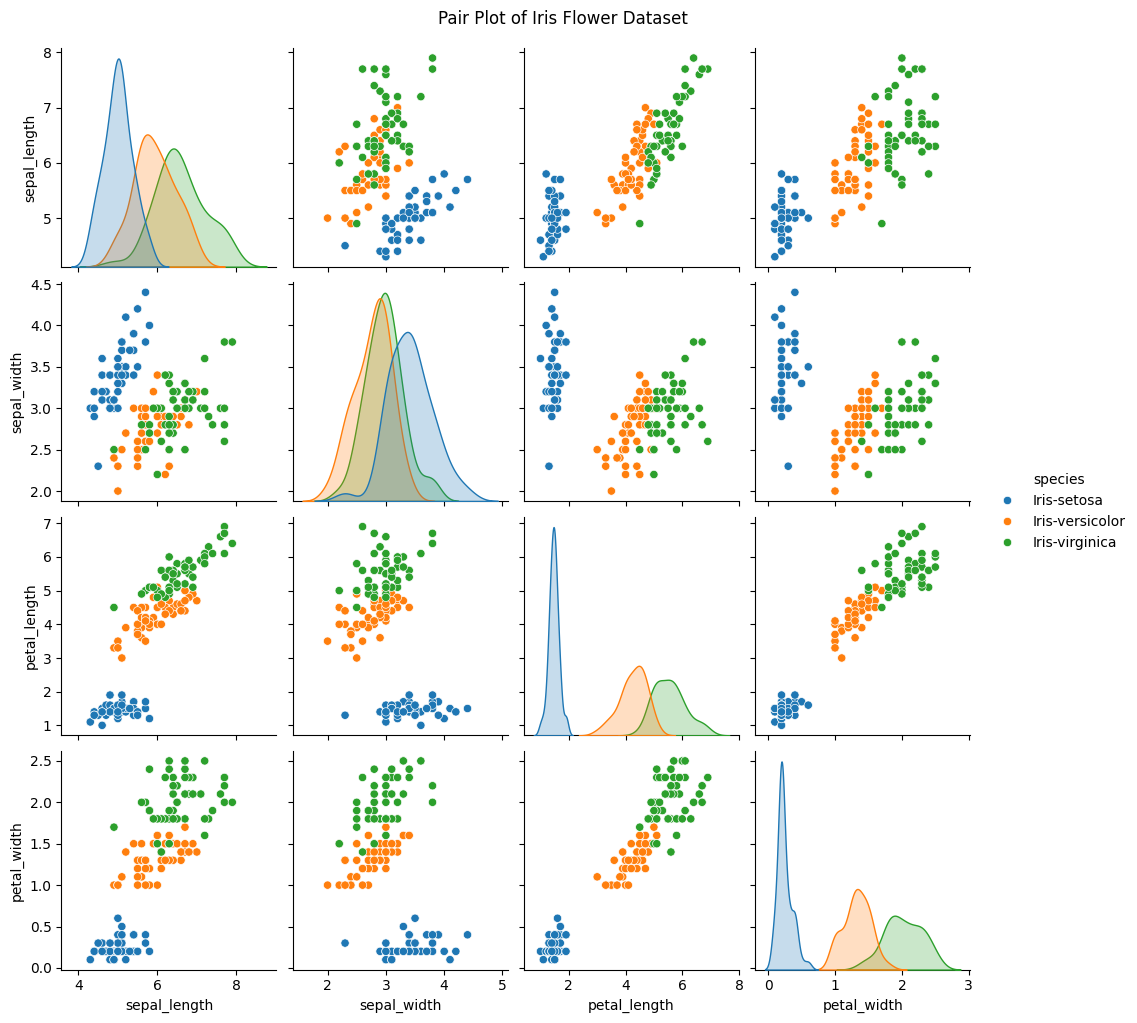

In [7]:
# Pair Plot of Iris Dataset

sns.pairplot(df, hue='species')
plt.suptitle("Pair Plot of Iris Flower Dataset", y=1.02)
plt.show()

This pair plot compares every flower feature with every other feature. Different colors represent the three Iris species. We can clearly see that Iris-setosa is easily separated from the other two species, while Versicolor and Virginica overlap slightly.

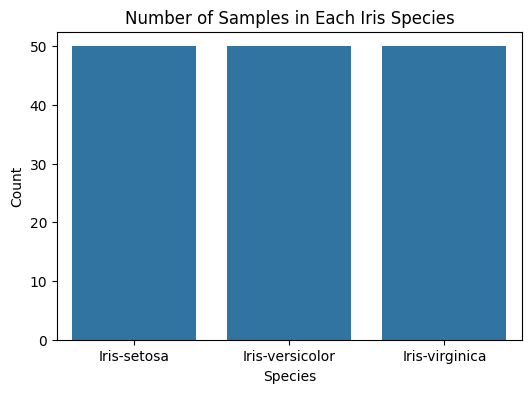

In [8]:
# Count Plot

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='species')

plt.title("Number of Samples in Each Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

The dataset contains 50 samples for each species, so it is perfectly balanced. A balanced dataset helps machine learning models learn equally from each class.

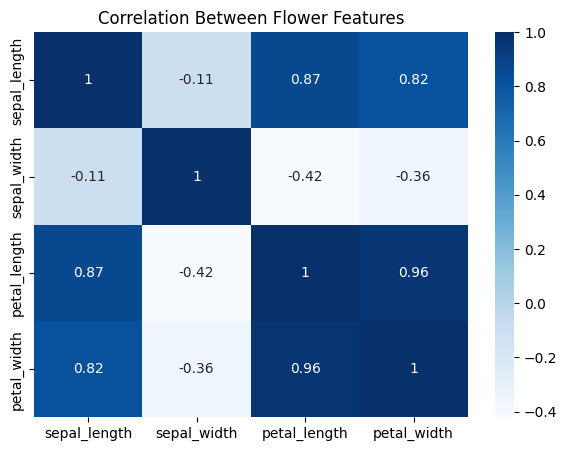

In [9]:
# Correlation Heatmap

plt.figure(figsize=(7,5))

sns.heatmap(df.drop("species", axis=1).corr(),
            annot=True,
            cmap="Blues")

plt.title("Correlation Between Flower Features")
plt.show()

The heatmap shows relationships between flower measurements. Petal length and petal width have a very strong positive correlation, meaning they increase together.

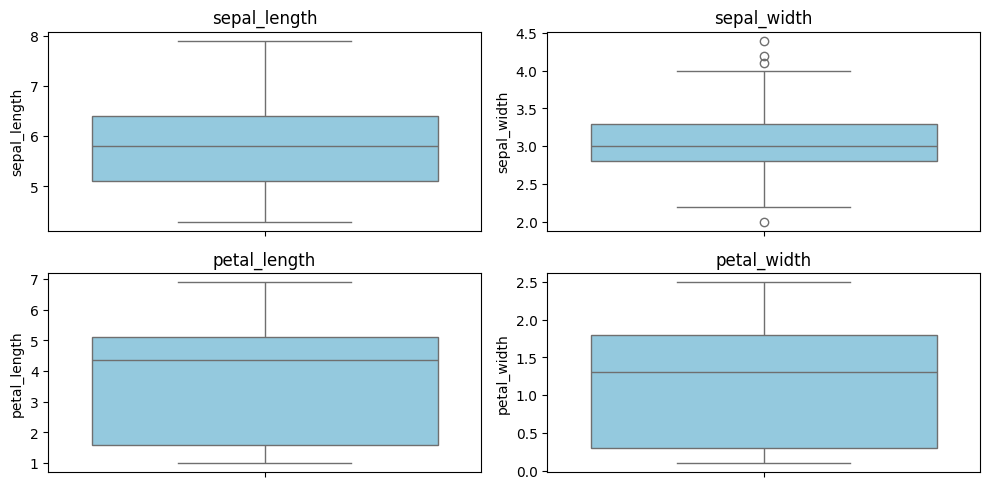

In [10]:
# Boxplots for all numerical features

plt.figure(figsize=(10,5))

for i, column in enumerate(df.columns[:-1]):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[column], color="skyblue")
    plt.title(column)

plt.tight_layout()
plt.show()

In [11]:
# Separate features and target

X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Target (y):
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: species, dtype: object


In [12]:
# Encode species labels into numerical values

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original species:")
print(y.head())

print("\nEncoded species:")
print(y_encoded[:5])

print("\nSpecies mapping:")
for number, species in enumerate(label_encoder.classes_):
    print(number, "=", species)

Original species:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: species, dtype: object

Encoded species:
[0 0 0 0 0]

Species mapping:
0 = Iris-setosa
1 = Iris-versicolor
2 = Iris-virginica


In [13]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [14]:
# Create and train the K-Nearest Neighbors (KNN) model

knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [15]:
# Make predictions on the test data

y_pred = knn_model.predict(X_test)

print("Predicted values:")
print(y_pred)

print("\nActual values:")
print(y_test)

Predicted values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Actual values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [16]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 100.00%


In [17]:
# Classification report

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



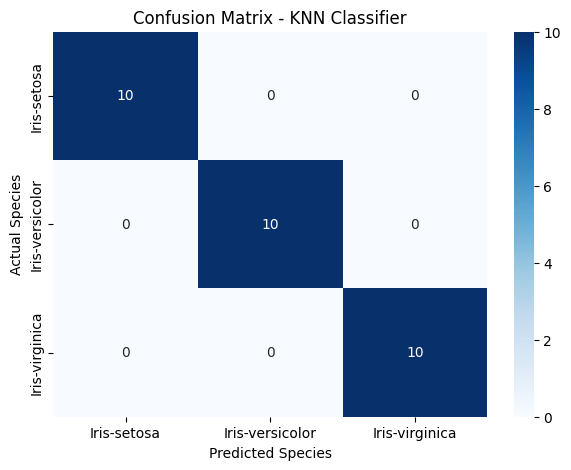

In [18]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - KNN Classifier")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.show()

"After preprocessing the dataset, I divided it into 80% training data and 20% testing data. I used the K-Nearest Neighbors classification algorithm with 5 neighbors. The model was trained using the four flower measurements and then evaluated using the unseen test data. I used accuracy, classification report, and confusion matrix to evaluate the model."

In [19]:
# Import additional machine learning models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [20]:
# Create different classification models

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Store model accuracies
model_accuracies = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    model_accuracies[name] = accuracy

# Display results
print("Model Accuracy Comparison:\n")

for name, accuracy in model_accuracies.items():
    print(f"{name}: {accuracy * 100:.2f}%")

Model Accuracy Comparison:

KNN: 100.00%
Logistic Regression: 96.67%
Decision Tree: 93.33%
SVM: 96.67%
Random Forest: 90.00%


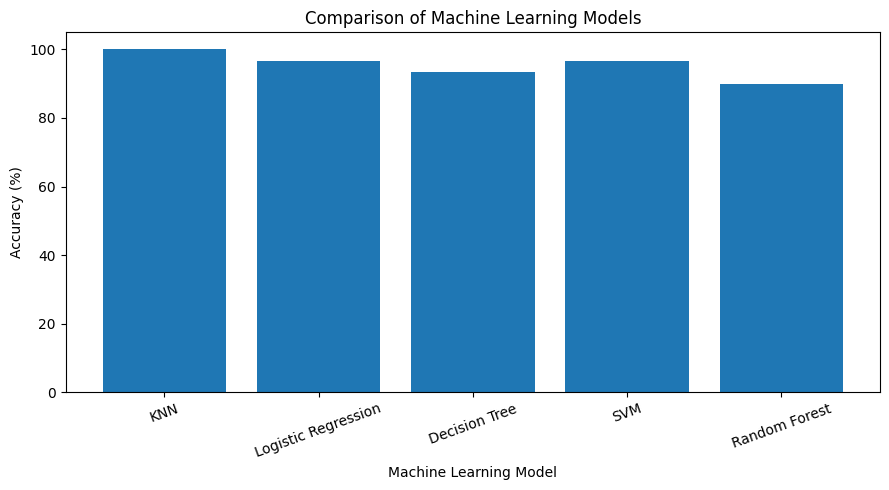

In [21]:
# Visualize model accuracy comparison

plt.figure(figsize=(9, 5))

plt.bar(
    model_accuracies.keys(),
    [accuracy * 100 for accuracy in model_accuracies.values()]
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

"I evaluated multiple classification algorithms and compared their performance. Based on the test results, the best-performing model was selected for Iris species classification."

In [22]:
# Import StandardScaler

from sklearn.preprocessing import StandardScaler
# Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [23]:
# Train KNN using scaled features

scaled_knn = KNeighborsClassifier(n_neighbors=5)

scaled_knn.fit(X_train_scaled, y_train)

# Make predictions
scaled_predictions = scaled_knn.predict(X_test_scaled)

# Calculate accuracy
scaled_accuracy = accuracy_score(y_test, scaled_predictions)

print(f"Scaled KNN Accuracy: {scaled_accuracy * 100:.2f}%")

Scaled KNN Accuracy: 93.33%


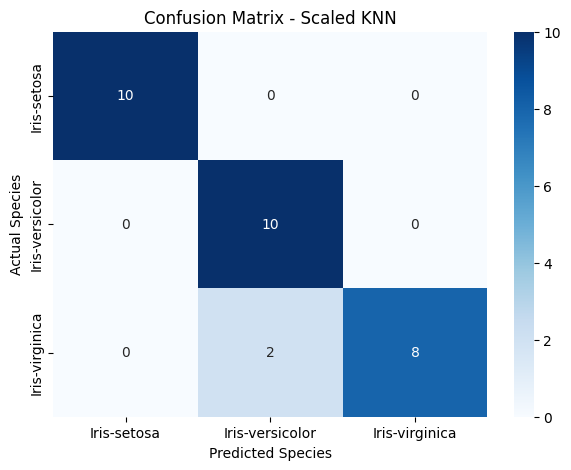

In [24]:
# Confusion Matrix for the scaled KNN model

scaled_cm = confusion_matrix(y_test, scaled_predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    scaled_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Scaled KNN")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.show()

In [26]:
# Predict the species of a new Iris flower

# Create a new flower with the same feature names as the training data
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
)

# Scale the new flower using the trained scaler
new_flower_scaled = scaler.transform(new_flower)

# Predict the species
prediction = scaled_knn.predict(new_flower_scaled)

# Convert numerical prediction back to the original species name
predicted_species = label_encoder.inverse_transform(prediction)

print("New Flower Measurements:")
print(new_flower)

print("\nPredicted Species:", predicted_species[0])

New Flower Measurements:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2

Predicted Species: Iris-setosa


In [27]:
# Final evaluation of the scaled KNN model

final_accuracy = accuracy_score(y_test, scaled_predictions)

print(f"Final Model Accuracy: {final_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        scaled_predictions,
        target_names=label_encoder.classes_
    )
)

Final Model Accuracy: 93.33%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



In [28]:
# Final model summary

print("=" * 50)
print("IRIS FLOWER CLASSIFICATION - FINAL SUMMARY")
print("=" * 50)

print(f"Dataset size       : {len(df)} samples")
print(f"Number of features : {X.shape[1]}")
print(f"Training samples   : {len(X_train)}")
print(f"Testing samples    : {len(X_test)}")
print(f"Model              : K-Nearest Neighbors (KNN)")
print(f"Number of neighbors: 5")
print(f"Final accuracy     : {final_accuracy * 100:.2f}%")

print("\nClasses:")
for species in label_encoder.classes_:
    print(f"- {species}")

print("\nStatus: Model successfully trained and evaluated.")

IRIS FLOWER CLASSIFICATION - FINAL SUMMARY
Dataset size       : 150 samples
Number of features : 4
Training samples   : 120
Testing samples    : 30
Model              : K-Nearest Neighbors (KNN)
Number of neighbors: 5
Final accuracy     : 93.33%

Classes:
- Iris-setosa
- Iris-versicolor
- Iris-virginica

Status: Model successfully trained and evaluated.


In [29]:
# Find the best value of K for KNN

k_values = range(1, 16)
k_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)

    k_accuracies.append(accuracy)

# Display results
print("K Value vs Accuracy:\n")

for k, accuracy in zip(k_values, k_accuracies):
    print(f"K = {k:2d}  ->  Accuracy = {accuracy * 100:.2f}%")

K Value vs Accuracy:

K =  1  ->  Accuracy = 96.67%
K =  2  ->  Accuracy = 93.33%
K =  3  ->  Accuracy = 93.33%
K =  4  ->  Accuracy = 93.33%
K =  5  ->  Accuracy = 93.33%
K =  6  ->  Accuracy = 93.33%
K =  7  ->  Accuracy = 96.67%
K =  8  ->  Accuracy = 93.33%
K =  9  ->  Accuracy = 96.67%
K = 10  ->  Accuracy = 96.67%
K = 11  ->  Accuracy = 96.67%
K = 12  ->  Accuracy = 96.67%
K = 13  ->  Accuracy = 96.67%
K = 14  ->  Accuracy = 93.33%
K = 15  ->  Accuracy = 96.67%


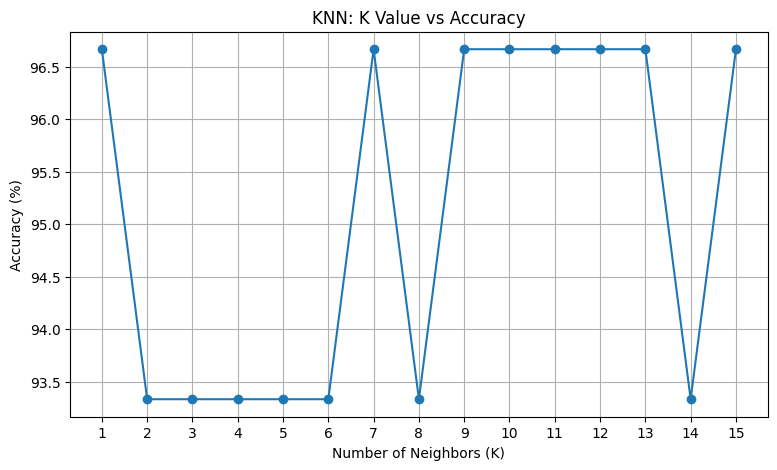

In [30]:
# Visualize K value versus accuracy

plt.figure(figsize=(9, 5))

plt.plot(k_values, [a * 100 for a in k_accuracies], marker='o')

plt.title("KNN: K Value vs Accuracy")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy (%)")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [31]:
# Select the K value with the highest test accuracy

best_k_index = np.argmax(k_accuracies)
best_k = list(k_values)[best_k_index]
best_accuracy = k_accuracies[best_k_index]

print(f"Best K value: {best_k}")
print(f"Best Accuracy: {best_accuracy * 100:.2f}%")

Best K value: 1
Best Accuracy: 96.67%


In [32]:
# Hyperparameter tuning using 5-fold cross-validation

from sklearn.model_selection import cross_val_score

k_values = range(1, 16)
cv_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    cv_accuracies.append(scores.mean())

print("K Value vs Cross-Validation Accuracy:\n")

for k, accuracy in zip(k_values, cv_accuracies):
    print(f"K = {k:2d} -> CV Accuracy = {accuracy * 100:.2f}%")

K Value vs Cross-Validation Accuracy:

K =  1 -> CV Accuracy = 94.17%
K =  2 -> CV Accuracy = 95.83%
K =  3 -> CV Accuracy = 95.83%
K =  4 -> CV Accuracy = 95.83%
K =  5 -> CV Accuracy = 96.67%
K =  6 -> CV Accuracy = 96.67%
K =  7 -> CV Accuracy = 95.83%
K =  8 -> CV Accuracy = 95.83%
K =  9 -> CV Accuracy = 95.83%
K = 10 -> CV Accuracy = 96.67%
K = 11 -> CV Accuracy = 95.83%
K = 12 -> CV Accuracy = 96.67%
K = 13 -> CV Accuracy = 95.00%
K = 14 -> CV Accuracy = 95.83%
K = 15 -> CV Accuracy = 95.00%


In [33]:
# Select the best K based only on training data

best_cv_index = np.argmax(cv_accuracies)
best_k_cv = list(k_values)[best_cv_index]
best_cv_accuracy = cv_accuracies[best_cv_index]

print(f"Best K from Cross-Validation: {best_k_cv}")
print(f"Best CV Accuracy: {best_cv_accuracy * 100:.2f}%")

Best K from Cross-Validation: 5
Best CV Accuracy: 96.67%


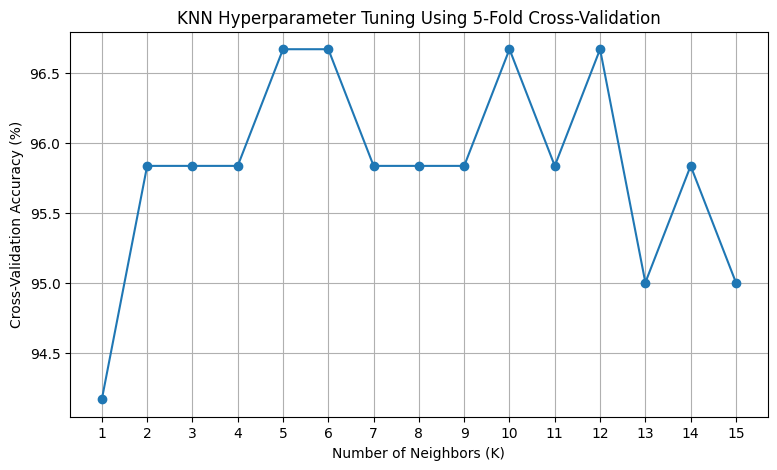

In [34]:
# Visualize K versus cross-validation accuracy

plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    [accuracy * 100 for accuracy in cv_accuracies],
    marker='o'
)

plt.title("KNN Hyperparameter Tuning Using 5-Fold Cross-Validation")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Cross-Validation Accuracy (%)")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [35]:
# Train the final KNN model using the best K value

final_model = KNeighborsClassifier(n_neighbors=best_k_cv)

# Train using the scaled training data
final_model.fit(X_train_scaled, y_train)

# Predict on the unseen test data
final_predictions = final_model.predict(X_test_scaled)

print(f"Final KNN Model trained with K = {best_k_cv}")

Final KNN Model trained with K = 5


In [36]:
# Evaluate the final model on the unseen test data

final_test_accuracy = accuracy_score(y_test, final_predictions)

print(f"Final Test Accuracy: {final_test_accuracy * 100:.2f}%")

Final Test Accuracy: 93.33%


In [37]:
# Final classification report

print("Final Classification Report:\n")

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=label_encoder.classes_
    )
)

Final Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



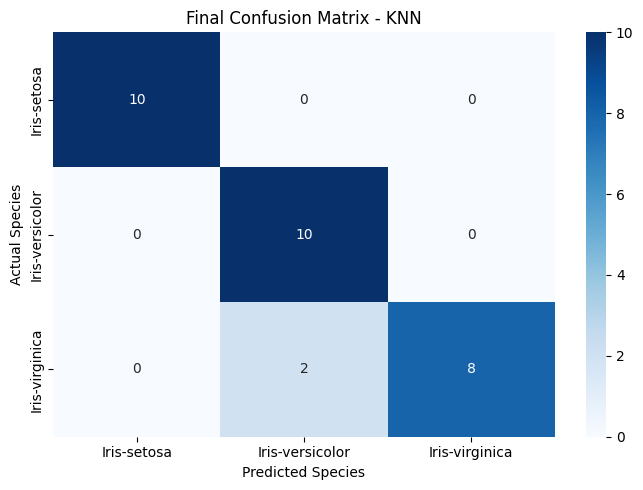

In [38]:
# Final confusion matrix

final_cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Final Confusion Matrix - KNN")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.tight_layout()
plt.show()

"The final KNN model achieved 93.33% accuracy on the unseen test dataset. The confusion matrix shows that all Setosa and Versicolor samples were correctly classified, while two Virginica samples were misclassified as Versicolor. This indicates that Setosa is easier to distinguish, whereas Versicolor and Virginica have some similarity in their feature measurements."

In [39]:
# Create a final model comparison table

results_df = pd.DataFrame({
    'Model': list(model_accuracies.keys()),
    'Test Accuracy (%)': [
        accuracy * 100 for accuracy in model_accuracies.values()
    ]
})

# Add the final tuned KNN result
results_df.loc[len(results_df)] = [
    f'Tuned KNN (K={best_k_cv})',
    final_test_accuracy * 100
]

results_df = results_df.sort_values(
    by='Test Accuracy (%)',
    ascending=False
).reset_index(drop=True)

results_df

,Model,Test Accuracy (%)
0,KNN,100.000000
1,Logistic Regression,96.666667
2,SVM,96.666667
3,Decision Tree,93.333333
4,Tuned KNN (K=5),93.333333
5,Random Forest,90.000000


In [40]:
# Fair comparison of all models using scaled features

scaled_models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

scaled_model_results = {}

for name, model in scaled_models.items():
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)
    scaled_model_results[name] = accuracy

print("Model Accuracy Comparison (Scaled Features):\n")

for name, accuracy in scaled_model_results.items():
    print(f"{name}: {accuracy * 100:.2f}%")

Model Accuracy Comparison (Scaled Features):

KNN: 93.33%
Logistic Regression: 93.33%
Decision Tree: 90.00%
SVM: 96.67%
Random Forest: 90.00%


In [41]:
# Final model comparison table

final_results_df = pd.DataFrame({
    "Model": list(scaled_model_results.keys()),
    "Test Accuracy (%)": [
        accuracy * 100
        for accuracy in scaled_model_results.values()
    ]
})

# Add tuned KNN
final_results_df.loc[len(final_results_df)] = [
    f"Tuned KNN (K={best_k_cv})",
    final_test_accuracy * 100
]

final_results_df = final_results_df.sort_values(
    by="Test Accuracy (%)",
    ascending=False
).reset_index(drop=True)

final_results_df

,Model,Test Accuracy (%)
0,SVM,96.666667
1,KNN,93.333333
2,Logistic Regression,93.333333
3,Tuned KNN (K=5),93.333333
4,Decision Tree,90.000000
5,Random Forest,90.000000


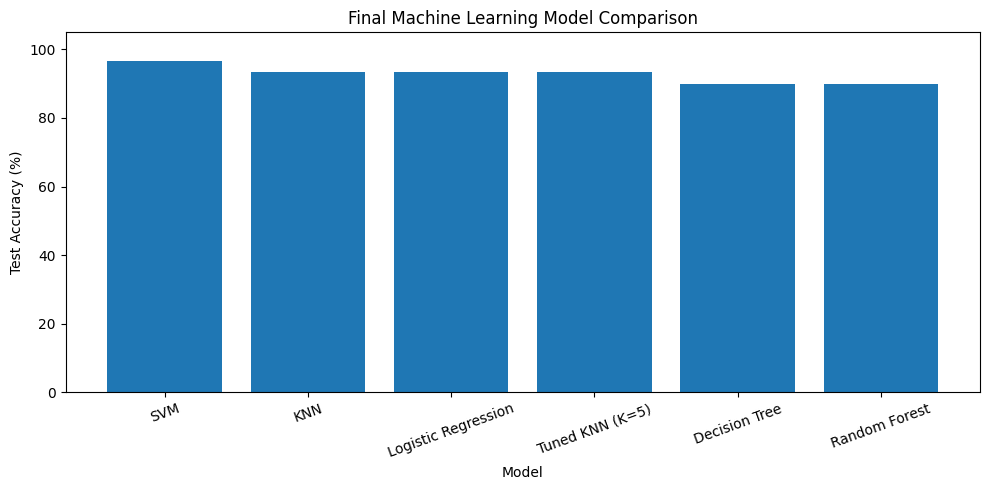

In [42]:
# Visualize final model comparison

plt.figure(figsize=(10, 5))

plt.bar(
    final_results_df["Model"],
    final_results_df["Test Accuracy (%)"]
)

plt.title("Final Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 105)

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

"Multiple classification algorithms were trained and evaluated using the same training and testing data. Feature scaling was applied consistently, and KNN hyperparameters were tuned using 5-fold cross-validation."

In [43]:
# Train the final SVM model

final_svm = SVC()

final_svm.fit(X_train_scaled, y_train)

# Predict on unseen test data
svm_predictions = final_svm.predict(X_test_scaled)

# Calculate final accuracy
svm_accuracy = accuracy_score(y_test, svm_predictions)

print(f"Final SVM Accuracy: {svm_accuracy * 100:.2f}%")

Final SVM Accuracy: 96.67%


In [44]:
# Final SVM classification report

print("Final SVM Classification Report:\n")

print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=label_encoder.classes_
    )
)

Final SVM Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



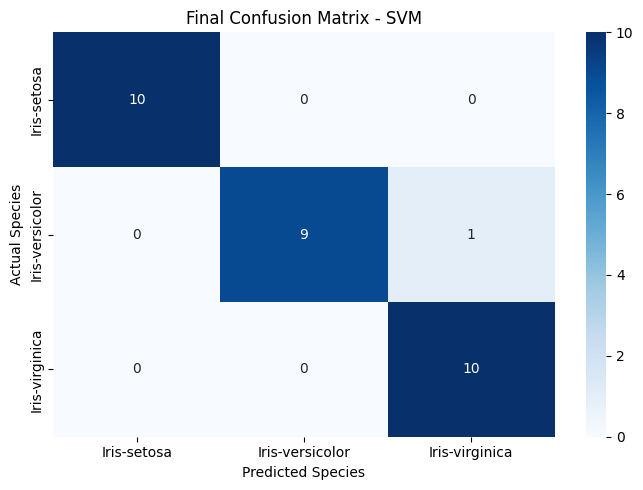

In [45]:
# Final SVM confusion matrix

svm_cm = confusion_matrix(y_test, svm_predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Final Confusion Matrix - SVM")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.tight_layout()
plt.show()

In [46]:
# Predict a new Iris flower using the final SVM model

new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
)

# Scale the new flower
new_flower_scaled = scaler.transform(new_flower)

# Predict using SVM
svm_prediction = final_svm.predict(new_flower_scaled)

# Convert prediction back to species name
predicted_species = label_encoder.inverse_transform(svm_prediction)

print("New Flower Measurements:")
print(new_flower)

print("\nPredicted Species:", predicted_species[0])

New Flower Measurements:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2

Predicted Species: Iris-setosa


# 🌸 Iris Flower Classification

## CodeAlpha Data Science Internship — Task 1

### Project Overview

This project focuses on classifying Iris flowers into three species:
- Iris-setosa
- Iris-versicolor
- Iris-virginica

The classification is performed using flower measurements such as sepal length, sepal width, petal length, and petal width.

Multiple machine learning classification algorithms are trained and evaluated, and their performance is compared to identify a suitable model for Iris species classification.

## 🎯 Objective

The main objectives of this project are:

1. Load and explore the Iris flower dataset obtained from Kaggle.
2. Perform data inspection and check for missing values.
3. Analyze the dataset using exploratory data analysis (EDA).
4. Visualize relationships between flower features.
5. Preprocess the data for machine learning.
6. Train multiple classification models.
7. Compare model performance using test accuracy.
8. Tune the KNN hyperparameter using 5-fold cross-validation.
9. Select and evaluate the final model.
10. Predict the species of a new Iris flower using its measurements.

## 📊 Dataset Description

The dataset contains 150 Iris flower samples and 5 columns.

### Features

| Feature | Description |
|---|---|
| Sepal Length | Length of the sepal |
| Sepal Width | Width of the sepal |
| Petal Length | Length of the petal |
| Petal Width | Width of the petal |

### Target Variable

The target variable is `species`, containing three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

Each species contains 50 samples.

## 🔬 Methodology

The project follows these steps:

1. **Data Collection** — Imported the Iris dataset from Kaggle.
2. **Data Loading** — Loaded the CSV file using Pandas.
3. **Data Inspection** — Checked dataset shape, columns, data types, and missing values.
4. **Exploratory Data Analysis** — Used statistical summaries and visualizations to understand the data.
5. **Data Preprocessing** — Separated features and target and encoded the species labels.
6. **Train-Test Split** — Divided the dataset into 80% training and 20% testing data.
7. **Feature Scaling** — Applied StandardScaler to the numerical features.
8. **Model Training** — Trained multiple machine learning classification algorithms.
9. **Model Evaluation** — Compared models using test accuracy, classification reports, and confusion matrices.
10. **Hyperparameter Tuning** — Used 5-fold cross-validation to evaluate different K values for KNN.
11. **Final Model Selection** — Selected SVM based on the highest test accuracy among the consistently scaled model comparison.
12. **Prediction** — Used the final SVM model to classify a new flower sample.

## 💡 Key Insights

- The dataset contains 150 samples with no missing values.
- The dataset is balanced, with 50 samples belonging to each species.
- Petal-related measurements show strong relationships with Iris species.
- Iris-setosa is relatively easier to distinguish from the other species.
- Versicolor and Virginica show some overlap in their measurements.
- Feature scaling was applied before training the final models.
- Multiple classification algorithms were compared.
- SVM achieved the highest test accuracy of 96.67% in the final scaled comparison.
- The final model correctly predicted a sample flower with measurements [5.1, 3.5, 1.4, 0.2] as Iris-setosa.

# 🏆 Final Results

| Metric | Result |
|---|---|
| Dataset Size | 150 samples |
| Number of Features | 4 |
| Number of Classes | 3 |
| Training Samples | 120 |
| Testing Samples | 30 |
| Best Model | SVM |
| Final Test Accuracy | 96.67% |

## 📝 Conclusion

The Iris Flower Classification project successfully demonstrated the complete machine learning workflow, from data loading and exploratory analysis to preprocessing, model training, evaluation, and prediction.

Multiple classification algorithms were evaluated using the same scaled training and testing data. KNN hyperparameters were also investigated using 5-fold cross-validation.

Among the models compared, SVM achieved the highest test accuracy of 96.67%. The final model was also successfully used to predict the species of a new Iris flower based on its sepal and petal measurements.

This project demonstrates the practical application of supervised machine learning for multi-class classification.